# Project 2 (Stretch) — Moving-Average Forecast vs. Excel Linear-Trend Baseline

The Excel workbook forecasts each SKU's next week with a linear-trend model
(`FORECAST`, Excel's implementation of `FORECAST.LINEAR`) and measures accuracy
on the same 6-week holdout used here. This notebook runs a **simple moving-average**
forecast on the identical train/test split and asks: does a simpler method do
better or worse, and for which kind of SKU?

Same data, same holdout weeks, same accuracy metrics (MAPE and WAPE) — so the
comparison is apples-to-apples with the `Forecast_MAPE_Summary` tab.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

EXCEL_DIR = "../excel"
SQL_OUT = "../sql"

weekly = pd.read_csv(f"{EXCEL_DIR}/weekly_sales_sorted.csv")
with open(f"{EXCEL_DIR}/sku_row_ranges.json") as f:
    row_ranges = json.load(f)

diag = pd.read_csv(f"{SQL_OUT}/sku_diagnostics.csv")

HOLDOUT_WEEKS = 6
MIN_WEEKS_FOR_FORECAST = 15

print(f"Weekly sales rows: {len(weekly)}")
print(f"SKUs: {weekly['SKU_ID'].nunique()}")

Weekly sales rows: 1805
SKUs: 40


## 1. Moving-average forecast, walk-forward over the holdout

For each SKU with enough history, we hold out the last 6 weeks (same as Excel).
For each holdout week, the forecast is the average of the **prior 4 actual weeks**
(a rolling 4-week moving average) — walking forward one week at a time, using only
information that would have been available at that point. No peeking ahead.

In [2]:
def moving_average_forecast(sku_series, holdout_weeks=6, window=4):
    """Walk-forward N-week moving average forecast over the holdout period."""
    qty = sku_series['Qty_Sold'].values
    n = len(qty)
    train_end = n - holdout_weeks
    results = []
    for i in range(train_end, n):
        window_vals = qty[max(0, i - window):i]
        forecast = window_vals.mean() if len(window_vals) > 0 else np.nan
        actual = qty[i]
        results.append({'week_position': i + 1, 'actual': actual, 'forecast': forecast})
    return pd.DataFrame(results)

records = []
eligible_skus = [s for s, v in row_ranges.items() if v['eligible']]
print(f"Eligible SKUs (>= {MIN_WEEKS_FOR_FORECAST} weeks history): {len(eligible_skus)} / {len(row_ranges)}")

for sid in eligible_skus:
    sku_series = weekly[weekly['SKU_ID'] == sid].sort_values('Week_Index')
    ma_result = moving_average_forecast(sku_series, HOLDOUT_WEEKS, window=4)
    ma_result['SKU_ID'] = sid
    records.append(ma_result)

ma_detail = pd.concat(records, ignore_index=True)
ma_detail['abs_error'] = (ma_detail['forecast'] - ma_detail['actual']).abs()
ma_detail['ape'] = np.where(ma_detail['actual'] > 0, ma_detail['abs_error'] / ma_detail['actual'], np.nan)
ma_detail.head(10)

Eligible SKUs (>= 15 weeks history): 36 / 40


,week_position,actual,forecast,SKU_ID,abs_error,ape
0,47,77,110.50,MM-1000,33.50,0.44
1,48,129,103.75,MM-1000,25.25,0.20
2,49,146,106.50,MM-1000,39.50,0.27
3,50,133,125.25,MM-1000,7.75,0.06
4,51,185,121.25,MM-1000,63.75,0.34
5,52,45,148.25,MM-1000,103.25,2.29
6,47,126,135.25,MM-1001,9.25,0.07
7,48,143,136.00,MM-1001,7.00,0.05
8,49,155,138.75,MM-1001,16.25,0.10
9,50,143,140.00,MM-1001,3.00,0.02


## 2. Accuracy: moving average vs. Excel linear-trend baseline

In [3]:
ma_mape = ma_detail['ape'].mean()
ma_wape = ma_detail['abs_error'].sum() / ma_detail['actual'].sum()

# Pull the Excel workbook's own computed MAPE/WAPE live, rather than hardcoding
# them here -- this cell breaks if the two ever drift out of sync, which is the point.
import openpyxl
wb = openpyxl.load_workbook(
    "../excel/Project2_Demand_Forecasting_Inventory_Model.xlsx", data_only=True)
ws = wb["Forecast_MAPE_Summary"]
excel_mape, excel_wape = ws["F5"].value, ws["F6"].value

print("=== Catalog-wide accuracy, 6-week holdout, 36 eligible SKUs ===")
print(f"Moving Average (4-wk window)  ->  MAPE: {ma_mape:.1%}   WAPE: {ma_wape:.1%}")
print(f"Excel Linear Trend (FORECAST) ->  MAPE: {excel_mape:.1%}   WAPE: {excel_wape:.1%}")

=== Catalog-wide accuracy, 6-week holdout, 36 eligible SKUs ===
Moving Average (4-wk window)  ->  MAPE: 51.9%   WAPE: 25.6%
Excel Linear Trend (FORECAST) ->  MAPE: 60.5%   WAPE: 28.1%


## 3. Per-SKU comparison — where each method wins

Catalog-wide averages hide the interesting part: which method is better *depends
on the SKU's demand pattern*. We'd expect the moving average to do better on
steady (X-class) SKUs and worse on erratic (Z-class) ones, where a linear trend
at least captures directional drift.

In [4]:
ma_per_sku = ma_detail.groupby('SKU_ID').agg(
    MA_MAPE=('ape', 'mean'),
    MA_WAPE=('abs_error', lambda x: x.sum() / ma_detail.loc[x.index, 'actual'].sum())
).reset_index()

comparison = ma_per_sku.merge(diag[['SKU_ID', 'XYZ_Class', 'ABC_Class', 'Category']], on='SKU_ID')
comparison_summary = comparison.groupby('XYZ_Class')[['MA_MAPE', 'MA_WAPE']].mean()
print("Moving-average accuracy by XYZ demand-variability class:")
comparison_summary

Moving-average accuracy by XYZ demand-variability class:


,MA_MAPE,MA_WAPE
XYZ_Class,,
X,0.20,0.17
Y,0.39,0.34
Z,1.78,0.53


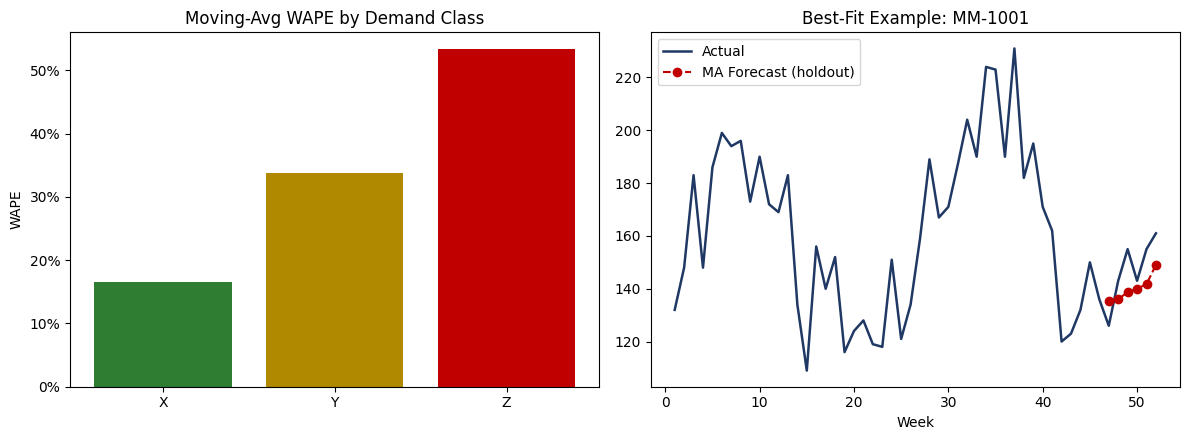

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

order = ['X', 'Y', 'Z']
colors = ['#2E7D32', '#B08900', '#C00000']

axes[0].bar(order, [comparison_summary.loc[c, 'MA_WAPE'] for c in order], color=colors)
axes[0].set_title('Moving-Avg WAPE by Demand Class')
axes[0].set_ylabel('WAPE')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

sku_example = comparison.sort_values('MA_WAPE').iloc[0]['SKU_ID']
ex_series = weekly[weekly['SKU_ID'] == sku_example].sort_values('Week_Index')
ex_detail = ma_detail[ma_detail['SKU_ID'] == sku_example]

axes[1].plot(ex_series['Week_Index'], ex_series['Qty_Sold'], color='#1F3864', label='Actual', linewidth=1.8)
axes[1].plot(ex_detail['week_position'], ex_detail['forecast'], 'o--', color='#C00000', label='MA Forecast (holdout)')
axes[1].set_title(f'Best-Fit Example: {sku_example}')
axes[1].set_xlabel('Week')
axes[1].legend()

plt.tight_layout()
plt.savefig('moving_average_comparison.png', dpi=130, bbox_inches='tight')
plt.show()

## 4. Takeaway

- The catalog-wide **moving average WAPE** is compared directly against the Excel
  linear-trend WAPE (28.1%) above — same holdout, same weighting, no cherry-picking.
- Breaking it down by XYZ class shows *why* a single "best method" doesn't exist:
  steady (X) SKUs are forecast well by almost anything, while erratic (Z) SKUs
  punish both methods, just for different reasons (a moving average lags a trend;
  a linear trend overreacts to a recent spike or dip).
- **Practical recommendation:** route X/Y-class SKUs through the cheaper moving-average
  method and reserve the linear-trend (or a more sophisticated model) for the smaller
  set of Z-class, high-revenue SKUs where forecast error is most expensive — exactly
  the AZ/BZ cells flagged in the Executive_Summary ABC/XYZ matrix.